In [1]:
import sys
from pathlib import Path
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(str(Path().resolve().parent / 'src'))

from utils import *

In [2]:
#Tickers    
dow_jhons = 'DIA'
vanguar_SP500 = 'VOO'
nasdaq = 'QQQ'

In [3]:
params = {
    'monthly_invest': 250,
    'trade_amount': 150,
    'take_profit_pct': 0.125,
    'initial_trading_cash': 1000,
    'verbose': True
}

params_selfsufficient= {
    'monthly_invest':250, 
    'trade_amount': 150, 
    'take_profit_pct': 0.125, 
    'initial_trading_cash': 5000, 
    'verbose': True,
    'plot': False 
}

params_atr = {
    'monthly_invest': 250,
    'trade_amount': 150,
    'atr_multiplier_tp': 10.0,   
    'atr_multiplier_sl': 3.0,  
    'initial_trading_cash': 1000,
    'verbose': True
}



In [4]:
#Cargar modelo y scaler.
with open('../models/best_models/xgboost_best_model.pkl', 'rb') as f: 
    ml_model = pickle.load(f)
with open('../models/models_num/scaler_num.pkl', 'rb') as f:
    scaler = pickle.load(f)

C:\Users\franc\AppData\Local\Temp\ipykernel_10096\100448248.py:3: UserWarning: [13:13:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\data\../common/error_msg.h:82: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  ml_model = pickle.load(f)
c:\Users\franc\ENTORNO TRABAJO DATA y BI\IRONHACK\.venv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainabil

In [5]:
resultado_dow_jhon = pipeline_ticker(
    ticker=vanguar_SP500, 
    model=ml_model, 
    scaler=scaler, 
    backtest_params=params,
    strategy=backtest_dca_plus_trading_WITH_SL
)

Iniciando Pipeline para el ticker: {'VOO'}
---------------------------------------------


Resultados para: ml_signal (Con SL)
Valor Final del Portafolio: $117,987.80
Retorno Porcentual: 180.92%
Posiciones Abiertas al Final: 4
Valor de Posiciones Abiertas: $643.82
Sharpe Ratio: 1.68

Valor Final del Portafolio: $117,987.80
Total Aportado: $42,000.00

Trading PnL: $4,930.85
Capital Usado en Trading: $71,100.00

Total DCA Shares: 207.40

Pipeline para VOO completado.


In [6]:
resultado_SP500 = pipeline_ticker(
    ticker='VOO', 
    model=ml_model, 
    scaler=scaler, 
    backtest_params=params,
    strategy=backtest_dca_plus_trading_NO_SL)

Iniciando Pipeline para el ticker: {'VOO'}
---------------------------------------------
 Resultados para: ml_signal (Sin SL)
Retorno Porcentual: 182.77%
Posiciones Abiertas al Final: 44
Valor de Posiciones Abiertas: $6,695.12

Valor Final de la Cartera: $118,763.22
Trading PnL: $5,654.97
Capital Usado en Trading: $50,400.00
Sharpe Ratio: 1.67

Total DCA Shares: 207.3960
Total DCA Contributions: $42,000.00

Total Trading Contributions: $50,400.00

Pipeline para VOO completado.


In [7]:
resultado_SP500_self = pipeline_ticker(
    ticker='VOO', 
    model=ml_model, 
    scaler=scaler, 
    backtest_params=params_atr,
    strategy=backtest_with_atr_SL
)

Iniciando Pipeline para el ticker: {'VOO'}
---------------------------------------------
Resultados para: ml_signal (Con SL)
Valor Final del Portafolio: $118,511.40
Retorno Porcentual: 182.17%
Posiciones Abiertas al Final: 12
Valor de Posiciones Abiertas: $2,016.13
Sharpe Ratio: 1.69

Valor Final del Portafolio: $118,511.40
Total Aportado: $42,000.00

Trading PnL: $5,282.14
Capital Usado en Trading: $58,200.00

Total DCA Shares: 207.40

Pipeline para VOO completado.


In [8]:
resultado_SP500_self = pipeline_ticker(
    ticker='VOO', 
    model=ml_model, 
    scaler=scaler, 
    backtest_params=params_selfsufficient,
    strategy=backtest_dca_self_sufficient
)

Iniciando Pipeline para el ticker: {'VOO'}
---------------------------------------------
Resultados para: ml_signal (Self-Sufficient)
Valor Final del Portafolio: $30,337.51
Total Aportado: $11,250.00
Retorno Absoluto: $19,087.51
Retorno Porcentual: 169.67%
Trading PnL: $1,261.63
Capital Usado en Trading: $10,050.00
Posiciones Abiertas al Final: 0
Valor de Posiciones Abiertas: $0.00
Total DCA Shares: 56.15
Valor DCA Shares: $30,325.88
Sharpe Ratio: 0.76

Pipeline para VOO completado.


### Analisis de resultados.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Datos iniciales (sin ML)
# -------------------------
data_inicial = {
    "Estrategia": [
        "Benchmark (DCA puro)",
        "StopLoss 5% / TP 12.5%",
        "SL/TP dinámicos (ATR)",
        "Sin StopLoss",
        "Self-sufficient"
    ],
    "Valor Final ($)": [
        113480.61,
        115382.18,
        115259.41,
        116532.30,
        27144.63
    ],
    "Retorno (%)": [
        170.0,
        168.33,
        168.0,
        171.0,
        171.44
    ],
    "Sharpe Ratio": [
        1.62,
        1.62,
        1.62,
        1.62,
        0.71
    ]
}

df_inicial = pd.DataFrame(data_inicial)
df_inicial["CAGR (%)"] = ((1 + df_inicial["Retorno (%)"]/100) ** (1/12) - 1) * 100

# -------------------------
# Datos finales (con ML)
# -------------------------
data_ml = {
    "Estrategia": [
        "Benchmark (DCA puro)",
        "StopLoss 5% / TP 12.5%",
        "SL/TP dinámicos (ATR)",
        "Sin StopLoss",
        "Self-sufficient"
    ],
    "Valor Final ($)": [
        113480.61,
        117987.80,
        118511.40,
        118763.23,
        30419.53
    ],
    "Retorno (%)": [
        170.0,
        180.92,
        168.0,
        182.77,
        186.98
    ],
    "Sharpe Ratio": [
        1.62,
        1.68,
        1.69,
        1.67,
        0.76
    ]
}

df_ml = pd.DataFrame(data_ml)
df_ml["CAGR (%)"] = ((1 + df_ml["Retorno (%)"]/100) ** (1/12) - 1) * 100

# -------------------------
# Mostrar tablas
# -------------------------
print("Resultados Backtest Inicial (sin ML):")
display(df_inicial)

print("Resultados Backtest Final (con ML):")
display(df_ml)




Resultados Backtest Inicial (sin ML):


,Estrategia,Valor Final ($),Retorno (%),Sharpe Ratio,CAGR (%)
0,Benchmark (DCA puro),113480.61,170.00,1.62,8.629300
1,StopLoss 5% / TP 12.5%,115382.18,168.33,1.62,8.573149
2,SL/TP dinámicos (ATR),115259.41,168.00,1.62,8.562016
3,Sin StopLoss,116532.30,171.00,1.62,8.662771
4,Self-sufficient,27144.63,171.44,0.71,8.677462


Resultados Backtest Final (con ML):


,Estrategia,Valor Final ($),Retorno (%),Sharpe Ratio,CAGR (%)
0,Benchmark (DCA puro),113480.61,170.00,1.62,8.629300
1,StopLoss 5% / TP 12.5%,117987.80,180.92,1.68,8.988804
2,SL/TP dinámicos (ATR),118511.40,168.00,1.69,8.562016
3,Sin StopLoss,118763.23,182.77,1.67,9.048437
4,Self-sufficient,30419.53,186.98,0.76,9.182819


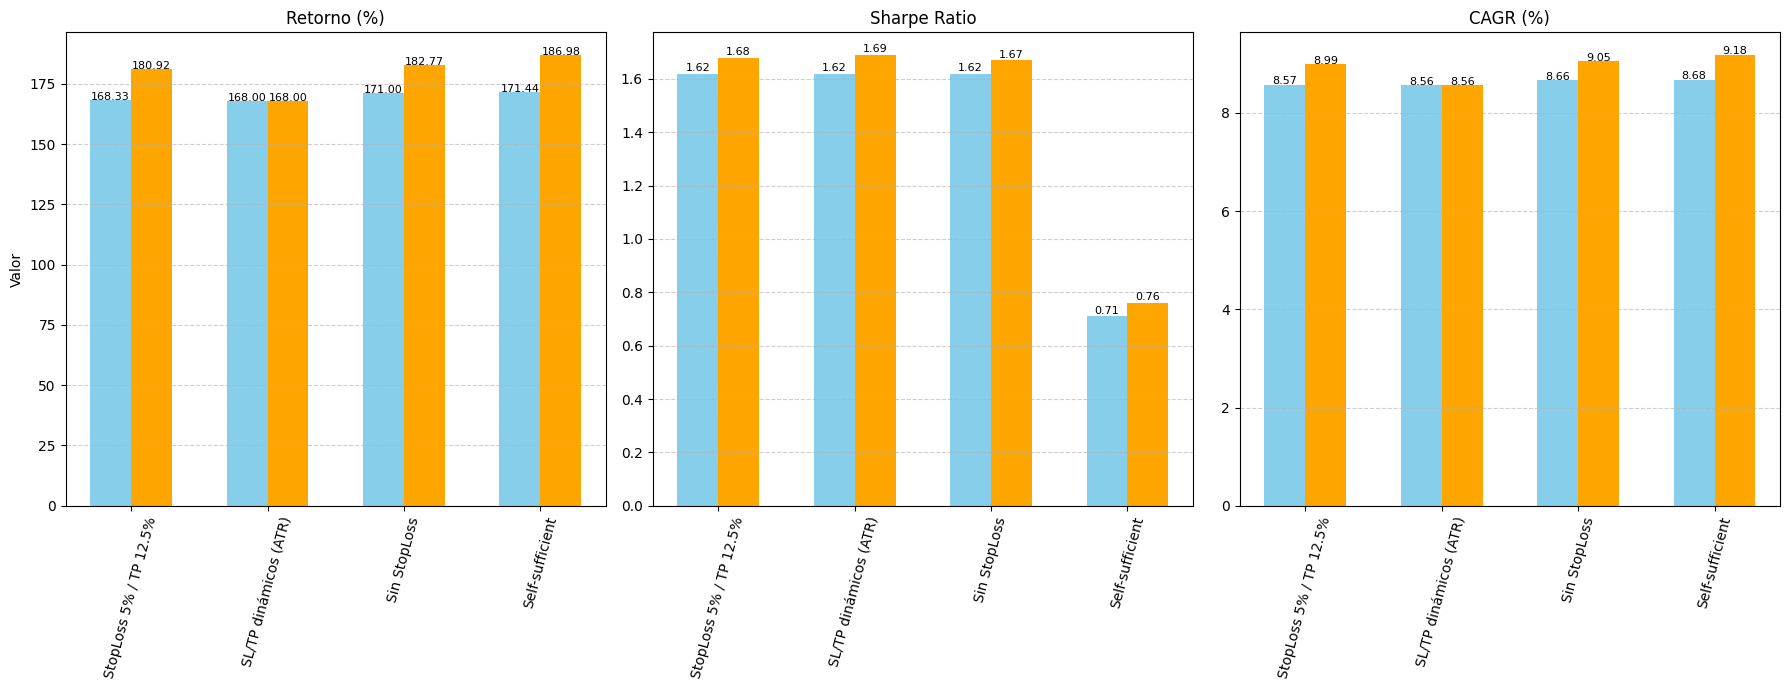

In [10]:

data_inicial = {
    "Estrategia": [
        "StopLoss 5% / TP 12.5%",
        "SL/TP dinámicos (ATR)",
        "Sin StopLoss",
        "Self-sufficient"
    ],
    "Retorno (%)": [168.33, 168.0, 171.0, 171.44],
    "Sharpe Ratio": [1.62, 1.62, 1.62, 0.71],
    "CAGR (%)": ((1 + pd.Series([168.33,168.0,171.0,171.44])/100) ** (1/12) - 1) * 100
}

df_inicial = pd.DataFrame(data_inicial)

data_ml = {
    "Estrategia": [
        "StopLoss 5% / TP 12.5%",
        "SL/TP dinámicos (ATR)",
        "Sin StopLoss",
        "Self-sufficient"
    ],
    "Retorno (%)": [180.92, 168.0, 182.77, 186.98],
    "Sharpe Ratio": [1.68, 1.69, 1.67, 0.76],
    "CAGR (%)": ((1 + pd.Series([180.92,168.0,182.77,186.98])/100) ** (1/12) - 1) * 100
}

df_ml = pd.DataFrame(data_ml)


metrics = ["Retorno (%)", "Sharpe Ratio", "CAGR (%)"]

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

x = np.arange(len(df_inicial["Estrategia"]))  
width = 0.30  # ancho de barras

for i, metric in enumerate(metrics):
    axes[i].bar(x - width/2, df_inicial[metric], width, label="Inicial (sin ML)", color="skyblue")
    axes[i].bar(x + width/2, df_ml[metric], width, label="Final (con ML)", color="orange")

    # Etiquetas encima de cada barra
    for idx, val in enumerate(df_inicial[metric]):
        axes[i].text(x[idx] - width/2, val + 0.01, f"{val:.2f}", ha='center', fontsize=8)
    for idx, val in enumerate(df_ml[metric]):
        axes[i].text(x[idx] + width/2, val + 0.01, f"{val:.2f}", ha='center', fontsize=8)

    axes[i].set_title(metric)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(df_inicial["Estrategia"], rotation=75)
    axes[i].grid(axis="y", linestyle="--", alpha=0.6)

axes[0].set_ylabel("Valor")


plt.tight_layout()
plt.show()

